# Modelado predictivo — Supervivencia a 5 años

**TFM:** Sistema de Apoyo a la Decisión Clínica en Oncología Pediátrica  
**Autor:** Alonso Castañón González  
**Dataset:** SEER Research Data — Osteosarcoma y Sarcoma de Ewing pediátrico (2000–2023)

**Objetivo de este notebook:** Entrenar y comparar modelos de clasificación binaria para predecir la supervivencia a 5 años,
partiendo de las conclusiones documentadas en `02_EDA.ipynb` (Sección 9). El modelo final se interpreta mediante SHAP.

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.dummy import DummyClassifier
from sklearn.metrics import roc_auc_score, average_precision_score, classification_report, confusion_matrix, make_scorer, accuracy_score, f1_score, recall_score, precision_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier


SEED = 2026
np.random.seed(SEED)

print("Entorno configurado correctamente")

Entorno configurado correctamente


## 1) Carga del dataset limpio y verificación

Se carga `seer_osteosarcoma_ewing_clean.parquet`, salida final de `01_limpieza.ipynb`, el mismo archivo usado en `02_EDA.ipynb`. Se verifica que el shape y los tipos de dato coinciden con lo documentado, para confirmar que se parte exactamente del mismo dataset.

In [2]:
DATA_PATH = '../data/seer_osteosarcoma_ewing_clean.parquet'
df = pd.read_parquet(DATA_PATH)

print(f"Shape: {df.shape}")

print("\n---- TIPOS DE DATOS ----")
print(df.dtypes)

print("\n---- PORCENTAJE DE VALORES MISSING POR COLUMNA ----")
missing_pct = (df.isnull().mean() * 100).round(1)
print(missing_pct[missing_pct > 0])

df.head(5)

Shape: (4915, 15)

---- TIPOS DE DATOS ----
age_group               category
sex                     category
year_diagnosis             int64
tumor_type              category
primary_site            category
stage                   category
tumor_size_cs            float64
surgery_code            category
radiation               category
chemotherapy            category
survival_months            int64
survival_months_flag    category
cause_specific_death    category
vital_status            category
target                     int64
dtype: object

---- PORCENTAJE DE VALORES MISSING POR COLUMNA ----
stage            19.2
tumor_size_cs    61.1
surgery_code      4.3
dtype: float64


,age_group,sex,year_diagnosis,tumor_type,primary_site,stage,tumor_size_cs,surgery_code,radiation,chemotherapy,survival_months,survival_months_flag,cause_specific_death,vital_status,target
0,05-09 years,Female,2004,Ewing sarcoma,Upper limb bones,Regional by direct extension only,64.0,Partial resection,Radiation,Yes,239,complete,Alive / Other cause,Alive,0
1,15-19 years,Male,2001,Ewing sarcoma,Trunk / ribs / sternum,NaN,NaN,Radical resection,No radiation,Yes,275,complete,Alive / Other cause,Alive,0
2,10-14 years,Female,2001,Ewing sarcoma,Pelvis / hip,NaN,NaN,No surgery,Radiation,Yes,119,complete,Dead (cancer),Dead,0
3,10-14 years,Female,2001,Osteosarcoma NOS,Lower limb bones,NaN,NaN,Radical resection,No radiation,Yes,274,complete,Alive / Other cause,Alive,0
4,15-19 years,Female,2000,Chondroblastic osteosarcoma,Pelvis / hip,NaN,NaN,No surgery,Radiation,Yes,23,complete,Dead (cancer),Dead,1


## 2) Eliminación de duplicados exactos

Como se comentó en la Sección 4 del notebook `02_EDA.ipynb`, se detectaron 74 filas duplicadas exactas concentradas en el missing de `tumor_size_cs`. Dadas las razones en dicha sección, estas filas duplicadas se eliminan antes del `train_test_split`, para evitar que una misma observación acabe repartida entre train y test y cause *data leakage*. Si eso ocurriera, el modelo podría aprender que hacer con esa fila en vez de generalizar, afectando a las métricas resultantes en el test, las cuales se inflarían artificialmente.

In [3]:
n_duplicados = df.duplicated().sum()
print(f"Duplicados exactos detectados: {n_duplicados}")

df = df.drop_duplicates().reset_index(drop=True)

print(f"Shape tras eliminar duplicados: {df.shape}")

Duplicados exactos detectados: 74
Shape tras eliminar duplicados: (4841, 15)


## 3) Agrupación de categorías minoritarias

Tres agrupaciones acordadas tras el EDA:

- **`tumor_type`**: se mantienen `Ewing sarcoma` y `Osteosarcoma NOS` ya que concentran la gran mayoría de casos y se agrupan los 7 subtipos menos comunes de osteosarcoma en `Osteosarcoma (other subtypes)`.
- **`stage`**: se agrupan las 3 categorías de afectación regional (`Regional by direct extension only`, `Regional lymph nodes involved only`, `Regional by both direct extension and lymph node involvement`) en un único nivel debido a al número de muestras y las curvas KM inestables vistas en la Sección 7. Quedan 3 niveles ordinales (`Localized < Regional < Distant`), coherente con el "Summary Stage" estándar de SEER.
- **`primary_site`**: se toma la decisión de mantenerla sin agrupar. Aunque `CNS/meninges` es la categoría más pequeña, en la Sección 5 del EDA se identifica precisamente `Pelvis/hip` y `CNS/meninges` como las dos localizaciones con peor pronóstico. Fusionarla con `Other/NOS` afectaría a esa información en vez de limpiar ruido. Lo único a considerar es que el tamaño muestral bajo afecta a la *estabilidad del coeficiente* en la Regresión Logística, uno de los modelos a probar, aunque no a la capacidad predictiva de Random Forest o XGBoost, que toleran bien categorías pequeñas. Se observará en SHAP si `CNS/meninges` muestra una contribución inestable y si es así se reconsiderará la agrupación.


In [4]:
# tumor_type
osteo_other = [
    'Chondroblastic osteosarcoma',
    'Telangiectatic osteosarcoma',
    'Central osteosarcoma',
    'Fibroblastic osteosarcoma',
    'Small cell osteosarcoma',
    'Intraosseous well differentiated osteosarcoma',
    'Osteosarcoma in Paget disease',
]

df['tumor_type'] = df['tumor_type'].astype(str).replace(
    {new: 'Osteosarcoma (other subtypes)' for new in osteo_other}
)
df['tumor_type'] = pd.Categorical(df['tumor_type'])

# stage
stage_map = {
    'Localized only': 'Localized',
    'Regional by direct extension only': 'Regional',
    'Regional lymph nodes involved only': 'Regional',
    'Regional by both direct extension and lymph node involvement': 'Regional',
    'Distant site(s)/node(s) involved': 'Distant',
}

df['stage'] = df['stage'].astype(str).map(stage_map)

stage_order = ['Localized', 'Regional', 'Distant']
df['stage'] = pd.Categorical(df['stage'], categories=stage_order, ordered=True)

print("---- tumor_type ----")
print(df['tumor_type'].value_counts())
print("\n---- stage ----")
print(df['stage'].value_counts(dropna=False).sort_index())

---- tumor_type ----
tumor_type
Ewing sarcoma                    2117
Osteosarcoma NOS                 1995
Osteosarcoma (other subtypes)     729
Name: count, dtype: int64

---- stage ----
stage
Localized    1360
Regional     1430
Distant      1131
NaN           920
Name: count, dtype: int64


## 4) Definición de X e y - división en train/test

Se define el conjunto de features excluyendo las variables de leakage (`survival_months`, `survival_months_flag`, `cause_specific_death`, `vital_status`) ya identificadas en
`01_limpieza.ipynb`. Se realiza un único `train_test_split` estratificado por `target`, común a los 4 modelos. `tumor_size_cs` se excluye como predictor principal, tal
como se decidió en el EDA (61.1% de missing estructural fuera de 2004-2015).

In [5]:
# Mismas listas que en el 02_EDA.ipynb pero aquí ya se incluye survival_months porque target depende directamente de ella
num_vars = ['year_diagnosis', 'tumor_size_cs', 'survival_months']
cat_vars = ['age_group', 'sex', 'tumor_type', 'primary_site', 'stage', 'surgery_code', 'radiation', 'chemotherapy']
target_var = 'target'

leakage_vars = ['survival_months', 'survival_months_flag', 'cause_specific_death', 'vital_status']
excluded_vars = ['tumor_size_cs'] + leakage_vars

feature_cols = [c for c in num_vars + cat_vars if c not in excluded_vars]
cat_model_vars = [c for c in cat_vars if c in feature_cols]
num_model_vars = [c for c in num_vars if c in feature_cols]
print("Features incluidas:", feature_cols)

X = df[feature_cols]
y = df[target_var]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=SEED)

print(f"\nTrain: {X_train.shape}, Test: {X_test.shape}")
print(f"Proporción target en train: {y_train.mean():.3f}")
print(f"Proporción target en test: {y_test.mean():.3f}")

Features incluidas: ['year_diagnosis', 'age_group', 'sex', 'tumor_type', 'primary_site', 'stage', 'surgery_code', 'radiation', 'chemotherapy']

Train: (3872, 9), Test: (969, 9)
Proporción target en train: 0.288
Proporción target en test: 0.288


## 5) Preprocesado por modelo

Cada modelo requiere un caso o `ColumnTransformer` distinto: 
- Dummy no necesita preprocesado. 
- Regresión Logística y Random Forest requieren imputación de `stage`/`surgery_code` (categoría explícita `"Unknown"` para no inventar información en la variable más predictiva) y codificación one-hot.
- Regresión Logística además necesita escalado de `year_diagnosis`. 
- XGBoost usa `NaN` y codificación categórica nativa, no es necesario imputar ni escalar.

Todo el preprocesado se define dentro de un `Pipeline`, de este modo así se recalcula en cada fold de la validación cruzada, y nunca sobre todo el conjunto train antes de hacer la división en folds.

In [6]:
# Preprocesado Regresión Logística
preprocessor_lr = ColumnTransformer(transformers=[
    ('cat', Pipeline([
        ('imputer', SimpleImputer(strategy='constant', fill_value='Unknown')),
        ('onehot', OneHotEncoder(handle_unknown='ignore'))
    ]), cat_model_vars),
    ('num', StandardScaler(), num_model_vars)
])

# Preprocesado RF
preprocessor_rf = ColumnTransformer(transformers=[
    ('cat', Pipeline([
        ('imputer', SimpleImputer(strategy='constant', fill_value='Unknown')),
        ('onehot', OneHotEncoder(handle_unknown='ignore'))
    ]), cat_model_vars),
    ('num', 'passthrough', num_model_vars)
])

### Preparación específica para XGBoost

Debido a lo comentado, XGBoost no usa `ColumnTransformer` con one-hot, ya que basta con que las columnas categóricas tengan dtype `category` de pandas y activar `enable_categorical=True` al instanciar el modelo (Sección 6). Los `NaN` se dejan sin imputar.

## 6) Modelos

Se entrenan y comparan cuatro modelos, cada uno con un propósito concreto en la narrativa del trabajo:

- **Dummy Classifier**: como su nombre indica, es un *clasificador tonto*, y sirve como referencia mínima ya que predice según la distribución de `target` sin usar ninguna feature. Cualquier modelo real debe superarlo claramente.
- **Regresión Logística**: baseline clásico, con coeficientes (odds ratios) fácilmente explicables. Sirve como referencia a cuánto aporta después la no linealidad de los modelos de árboles.
- **Random Forest**: baseline de ensemble. Se prescinde de un árbol de decisión individual, ya que un solo árbol es inestable y propenso al sobreajuste, y con este tamaño de dataset un RF lo supera casi sin excepción.
- **XGBoost**: en principio, modelo final del trabajo. Maneja de forma nativa los valores ausentes y las variables categóricas de alta cardinalidad. Es compatible con SHAP para la interpretabilidad clínica que requiere la capa predictiva del sistema.

Cada modelo, salvo Dummy obviamente, se ajusta mediante un `GridSearchCV` con `StratifiedKFold(5)`, optimizando la métrica PR-AUC (Precision-Recall Area Under the Curve) con `scoring='average_precision'` en vez de accuracy, F1-Score o ROC-AUC, dado el desbalanceo de clases y el coste clínico de un falso negativo frente a un falso positivo. 

Para cada modelo se analizarán las siguientes métricas sobre el conjunto de test:

- **PR-AUC** (criterio principal): métrica basada en el área bajo la curva Precision-Recall, mide la capacidad de distinguir la clase minoritaria en todo el rango de umbrales, sin verse afectada por el número de negativos como puede ocurrir con ROC-AUC en datasets desbalanceados.
- **ROC-AUC** (referencia): se reporta igualmente por ser la métrica más habitual en estos estudios y así facilitar la comparación.
- **Precision, recall y F1**: referencia inicial. Según los resultados obtenidos se puede probar el rendimiento que puede ofrecer FBeta-Score dándole más importancia al recall.
- **Matriz de confusión**: para visualizar directamente el volumen de falsos negativos, la categoría de mayor coste clínico en este problema.

Antes de comenzar con los modelos, se definen una serie de necesidades comunes entre ellos que sirven de ayuda para la realización del trabajo. En concreto, el esquema de validación cruzada (mismas particiones para los tres, para que sean comparables entre sí), el diccionario de métricas para `cross_validate`, una función para mostrar la
matriz de confusión, y un diccionario donde se irán guardando los resultados de cada modelo de cara a compararlos.

In [7]:
# Validación cruzada
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

# Métricas
scoring = {
    'accuracy': make_scorer(accuracy_score),
    'f1': make_scorer(f1_score, zero_division=0),
    'recall': make_scorer(recall_score, zero_division=0),
    'precision': make_scorer(precision_score, zero_division=0),
}

# Función para la matriz de confusión
def plot_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    df_cm = pd.DataFrame(cm, index=[0, 1], columns=[0, 1])
    sns.heatmap(df_cm, annot=True, cmap="Blues", fmt='d', cbar=False)
    plt.title(title)
    plt.tight_layout()
    plt.ylabel("Clase verdadera")
    plt.xlabel("Clase predicha")
    plt.show()

# Diccionario de resultados
resultados_modelos = {}

### 6.1) Dummy Classifier (base mínima)

Se entrena un `DummyClassifier` con `strategy='stratified'`, que predice, como se explicó, respetando la proporción observada de `target` (28.8%). En este caso no se aplica `GridSearchCV` al no tener hiperparámetros que ajustar.

              precision    recall  f1-score   support

           0      0.721     0.720     0.721       690
           1      0.311     0.312     0.311       279

    accuracy                          0.603       969
   macro avg      0.516     0.516     0.516       969
weighted avg      0.603     0.603     0.603       969



ROC-AUC: 0.516
PR-AUC:  0.295


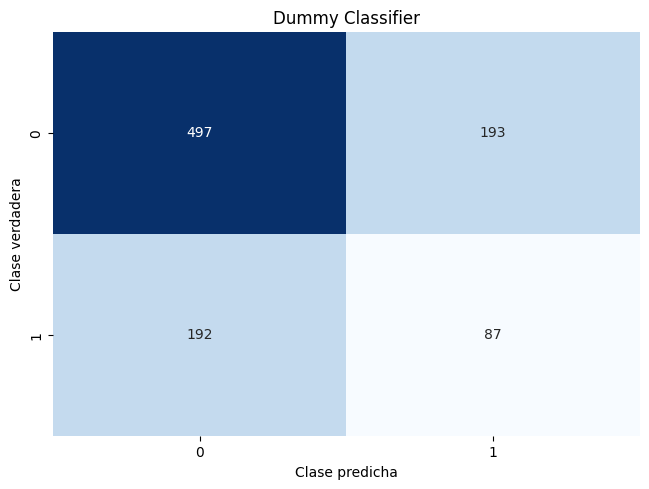

In [8]:
dummy = DummyClassifier(strategy='stratified', random_state=SEED)

dummy.fit(X_train, y_train)

y_pred_dummy = dummy.predict(X_test)
y_proba_dummy = dummy.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred_dummy, digits=3))
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba_dummy):.3f}")
print(f"PR-AUC:  {average_precision_score(y_test, y_proba_dummy):.3f}")

plot_confusion_matrix(y_test, y_pred_dummy, "Dummy Classifier")

resultados_modelos['Dummy'] = {
    'roc_auc': roc_auc_score(y_test, y_proba_dummy),
    'pr_auc': average_precision_score(y_test, y_proba_dummy),
    'y_pred': y_pred_dummy,
    'y_proba': y_proba_dummy,
}

>ROC-AUC=0.516 y PR-AUC=0.295, casi idéntico a la proporción real de positivos. Se confirma que el Dummy no aporta ninguna capacidad predictiva real, tal
como se espera. A partir de este punto, esta debe de ser la referencia y cualquier modelo con PR-AUC por debajo de aproximadamente 0.30
no estaría aportando nada a la predicción.

### 6.2) Regresión Logística

Se ajusta mediante `GridSearchCV` sobre el hiperparámetro de regularización `C`. Se comienza con el siguiente rango de valores de `C` posibles: [0.01, 0.1, 1, 10], pero en el caso de que se obtenga como mejor hiperparámetro un valor extremo, se modificará el array con valores más proximos a él. Se usa la `cv` común definida antes de la Sección 6.1, y `scoring='average_precision'` para la optimización.

In [9]:
lr = Pipeline([
    ('prep', preprocessor_lr),
    ('lr', LogisticRegression(max_iter=1000, random_state=SEED))
])

param_grid_lr = {
    'lr__C': [0.01, 0.1, 1, 10, 50, 100]
}

grid_lr = GridSearchCV(lr, param_grid_lr, scoring='average_precision', cv=cv, n_jobs=-1)

grid_lr.fit(X_train, y_train)

print("Mejores hiperparámetros:", grid_lr.best_params_)
print(f"Mejor PR-AUC en CV: {grid_lr.best_score_:.4f}")

Mejores hiperparámetros: {'lr__C': 10}
Mejor PR-AUC en CV: 0.5417


Accuracy: 0.735
F1-score: 0.356
Recall: 0.254
Precision: 0.592
ROC-AUC: 0.736
PR-AUC: 0.518


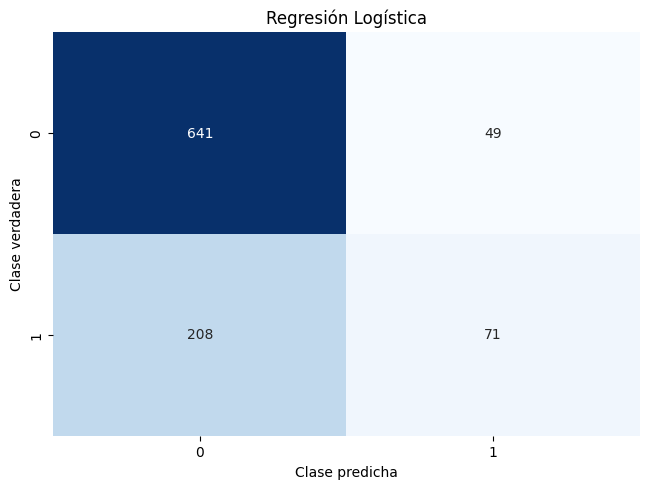

In [10]:
best_lr = grid_lr.best_estimator_

y_pred_test_lr = best_lr.predict(X_test)
y_proba_test_lr = best_lr.predict_proba(X_test)[:, 1]

print(f"Accuracy: {accuracy_score(y_test, y_pred_test_lr):.3f}")
print(f"F1-score: {f1_score(y_test, y_pred_test_lr):.3f}")
print(f"Recall: {recall_score(y_test, y_pred_test_lr):.3f}")
print(f"Precision: {precision_score(y_test, y_pred_test_lr):.3f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba_test_lr):.3f}")
print(f"PR-AUC: {average_precision_score(y_test, y_proba_test_lr):.3f}")

plot_confusion_matrix(y_test, y_pred_test_lr, "Regresión Logística")

resultados_modelos['Regresión Logística'] = {
    'roc_auc': roc_auc_score(y_test, y_proba_test_lr),
    'pr_auc': average_precision_score(y_test, y_proba_test_lr),
    'y_pred': y_pred_test_lr,
    'y_proba': y_proba_test_lr,
}

### 6.3) Random Forest

Se ajusta mediante `GridSearchCV` sobre `n_estimators`, `max_depth` y `min_samples_leaf`, con la misma `cv` y `scoring='average_precision'` que en Regresión Logística. Se usa `preprocessor_rf` (imputación `"Unknown"` + one-hot, sin escalado, ya que los árboles no lo necesitan).

In [11]:
rf = Pipeline([
    ('preprocessor', preprocessor_rf),
    ('rf', RandomForestClassifier(random_state=SEED, n_jobs=-1))
])

param_grid_rf = {
    'rf__n_estimators': [200, 400, 600],
    'rf__max_depth': [3, 5, 10],
    'rf__min_samples_leaf': [1, 5, 10],
    'rf__min_samples_split': [3, 5, 7],
}

grid_rf = GridSearchCV(rf, param_grid_rf, scoring='average_precision', cv=cv, n_jobs=-1)

grid_rf.fit(X_train, y_train)

print("Mejores hiperparámetros:", grid_rf.best_params_)
print(f"Mejor PR-AUC en CV: {grid_rf.best_score_:.4f}")

Mejores hiperparámetros: {'rf__max_depth': 5, 'rf__min_samples_leaf': 1, 'rf__min_samples_split': 5, 'rf__n_estimators': 400}
Mejor PR-AUC en CV: 0.5480


Accuracy:  0.733
F1-score:  0.162
Recall:    0.090
Precision: 0.833
ROC-AUC:   0.737
PR-AUC:    0.559


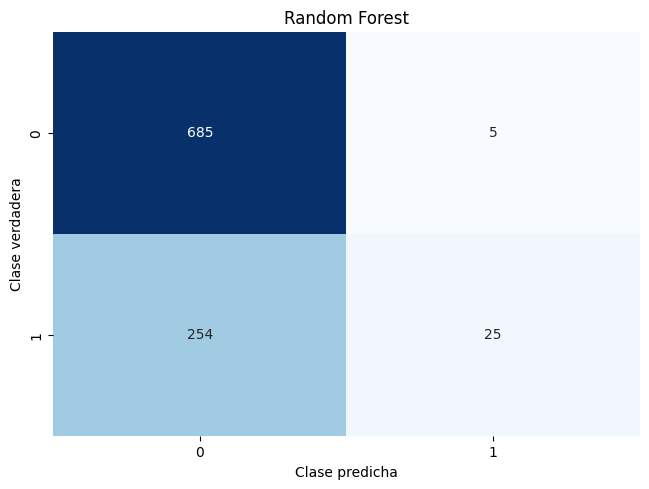

In [12]:
best_rf = grid_rf.best_estimator_
y_pred_test_rf = best_rf.predict(X_test)
y_proba_test_rf = best_rf.predict_proba(X_test)[:, 1]

print(f"Accuracy:  {accuracy_score(y_test, y_pred_test_rf):.3f}")
print(f"F1-score:  {f1_score(y_test, y_pred_test_rf):.3f}")
print(f"Recall:    {recall_score(y_test, y_pred_test_rf):.3f}")
print(f"Precision: {precision_score(y_test, y_pred_test_rf):.3f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_proba_test_rf):.3f}")
print(f"PR-AUC:    {average_precision_score(y_test, y_proba_test_rf):.3f}")

plot_confusion_matrix(y_test, y_pred_test_rf, "Random Forest")

resultados_modelos['Random Forest'] = {
    'roc_auc': roc_auc_score(y_test, y_proba_test_rf),
    'pr_auc': average_precision_score(y_test, y_proba_test_rf),
    'y_pred': y_pred_test_rf,
    'y_proba': y_proba_test_rf,
}

### 6.4) XGBoost

Se ajusta mediante `GridSearchCV` sobre `max_depth`, `learning_rate`, `n_estimators` y `subsample`, sin `ColumnTransformer`. Com se comentó, XGBoost gestiona los `NaN` y las columnas categóricas de pandas.

In [16]:
xgb = XGBClassifier(random_state=SEED, enable_categorical=True, tree_method='hist', eval_metric='aucpr')

param_grid_xgb = {
    'max_depth': [2, 3, 4],
    'learning_rate': [0.005, 0.01, 0.02, 0.03],
    'n_estimators': [400, 600, 800],
    'subsample': [0.8],
}

grid_xgb = GridSearchCV(xgb, param_grid_xgb, scoring='average_precision', cv=cv, n_jobs=-1)
grid_xgb.fit(X_train, y_train)

print("Mejores hiperparámetros:", grid_xgb.best_params_)
print(f"Mejor PR-AUC en CV: {grid_xgb.best_score_:.4f}")

Mejores hiperparámetros: {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 600, 'subsample': 0.8}
Mejor PR-AUC en CV: 0.5502


Accuracy:  0.746
F1-score:  0.391
Recall:    0.283
Precision: 0.632
ROC-AUC:   0.744
PR-AUC:    0.559


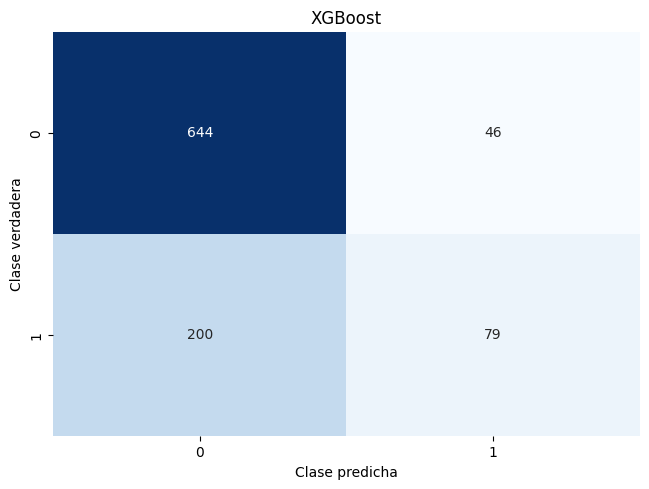

In [17]:
best_xgb = grid_xgb.best_estimator_
y_pred_test_xgb = best_xgb.predict(X_test)
y_proba_test_xgb = best_xgb.predict_proba(X_test)[:, 1]

print(f"Accuracy:  {accuracy_score(y_test, y_pred_test_xgb):.3f}")
print(f"F1-score:  {f1_score(y_test, y_pred_test_xgb):.3f}")
print(f"Recall:    {recall_score(y_test, y_pred_test_xgb):.3f}")
print(f"Precision: {precision_score(y_test, y_pred_test_xgb):.3f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_proba_test_xgb):.3f}")
print(f"PR-AUC:    {average_precision_score(y_test, y_proba_test_xgb):.3f}")

plot_confusion_matrix(y_test, y_pred_test_xgb, "XGBoost")

resultados_modelos['XGBoost'] = {
    'roc_auc': roc_auc_score(y_test, y_proba_test_xgb),
    'pr_auc': average_precision_score(y_test, y_proba_test_xgb),
    'y_pred': y_pred_test_xgb,
    'y_proba': y_proba_test_xgb,
}